## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1) regression is when the target/outcome variable y is numeric. Classification is done when the target/outcome variable y is categorical
2) A confusion table/matrix is when you cross tabulate the true labels with the predicted ones, and see if they align or not. It helps understand whether the model performance is making good or bad predictions
3) Accuracy is when you sum up the number of cases on the "descending diagnol" of the confusion matrix, and divide by the total number of observations. Accuracy may not be entirely sufficient to evaluate a classifers predictive performace due to a chance of an imbalanced dataset. An example would be when a majority of the class scores high on a test, and it leads it to not consider the small minority of students that failed the exam by the higher number of good scores masking the small bad ones.
4) root mean squared error allows to seek some kind of nice summary number for regression.

5) overfitting is if k is too low, then the model is overly sensitive to a large amount of data points. Underfitting is if k is picked too high, then the model averages over many observations and will give answers close to population proportions.
6) splitting the data into training and test data improve model performance by imagining that the test set is like the future cases not yet observed and model performance on the test set will be similar to future performance. Choosing k allows to evaluate the accuracy on the test set to see what values of k are best when confronted with new data
7) The prediction of a class label gives an immediate answer that is easy to interpret to people(stakeholders). The weakness of this method is that there is no indication if the model is confident in its work or just guessing. The probability distribution allows for customizing settings such as the threshold. It also gives a measure of the uncertainty. The weakness to this method is that it needs more interpretation than the other on the meaning of your numbers. There is more of a technical demand to get your numbers and interpret your work.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [3]:
#Get Data
! git clone https://github.com/Elizabethav03/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('./data/land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [6]:
print(df['mine_type'].value_counts())


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


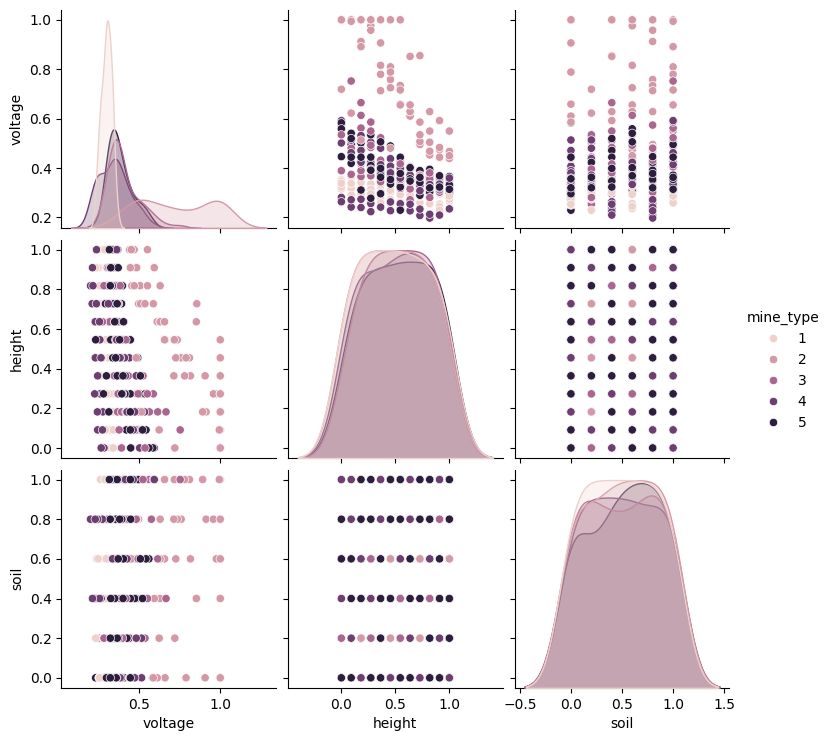

In [7]:
sns.pairplot(df,hue='mine_type')
plt.show()

In [8]:
#split the sample 50/50
from sklearn.model_selection import train_test_split
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

def minmax_scaler(x):
    return (x - x.min()) / (x.max() - x.min())

X_scaled = X.apply(minmax_scaler)
#50/50 splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 169
Test set size: 169

Training set class distribution:
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64

Test set class distribution:
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


Accuracy for 1 neighbors is 0.5088757396449705
Accuracy for 3 neighbors is 0.40828402366863903
Accuracy for 5 neighbors is 0.42011834319526625
Accuracy for 7 neighbors is 0.40236686390532544
Accuracy for 9 neighbors is 0.4319526627218935
Accuracy for 11 neighbors is 0.39644970414201186
Accuracy for 13 neighbors is 0.39644970414201186
Accuracy for 15 neighbors is 0.39644970414201186
Accuracy for 17 neighbors is 0.40236686390532544
Accuracy for 19 neighbors is 0.4260355029585799
Accuracy for 21 neighbors is 0.3905325443786982


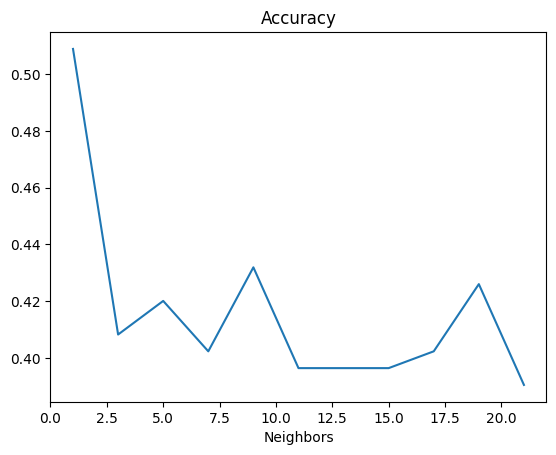

In [14]:
k_grid = np.arange(1, 22, 2) # More typical grid for k (odd numbers from 1 to 21)
accuracies = []
for k in k_grid: # For each candidate value of k...
    model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
    model = model.fit(X_train, y_train) # Fit the model on training data
    acc = model.score(X_test, y_test) # Compute accuracy on the test set
    print( f'Accuracy for {k} neighbors is {acc}')
    accuracies.append(acc) # Save accuracy

sns.lineplot(x=k_grid,y=accuracies).set(title='Accuracy',xlabel='Neighbors')
plt.show() # Added to ensure plot is displayed

In [12]:
#Build kNN Classifier
from sklearn.neighbors import KNeighborsClassifier
# Set the number of neighbors, typically odd to "break ties":
k = 5
# Create a fitted model instance:
model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
model = model.fit(X_train,y_train) # Fit the model, training set
y_hat = model.predict(X_test) # Predictions, test set
print( pd.crosstab(y_test, y_hat)) # Confusion matrix
model.score(X_test,y_test) # Test accuracy

col_0       1   2   3   4   5
mine_type                    
1          26   0   6   3   1
2           0  32   0   2   1
3           8   3   4   8  10
4          13   5   7   5   3
5           7   0  10  11   4


0.42011834319526625

In [17]:
best_knn = KNeighborsClassifier(n_neighbors= k)
best_knn.fit(X_train, y_train)

# Make predictions on test set
y_pred = best_knn.predict(X_test)

Test accuracy for 1 neighbors is 0.5088757396449705; train accuracy for 1 neighbors is 1.0
Test accuracy for 3 neighbors is 0.40828402366863903; train accuracy for 3 neighbors is 0.727810650887574
Test accuracy for 5 neighbors is 0.42011834319526625; train accuracy for 5 neighbors is 0.6982248520710059
Test accuracy for 7 neighbors is 0.40236686390532544; train accuracy for 7 neighbors is 0.5976331360946746
Test accuracy for 9 neighbors is 0.4319526627218935; train accuracy for 9 neighbors is 0.6094674556213018
Test accuracy for 11 neighbors is 0.39644970414201186; train accuracy for 11 neighbors is 0.591715976331361
Test accuracy for 13 neighbors is 0.39644970414201186; train accuracy for 13 neighbors is 0.591715976331361
Test accuracy for 15 neighbors is 0.39644970414201186; train accuracy for 15 neighbors is 0.5384615384615384
Test accuracy for 17 neighbors is 0.40236686390532544; train accuracy for 17 neighbors is 0.5443786982248521
Test accuracy for 19 neighbors is 0.4260355029585

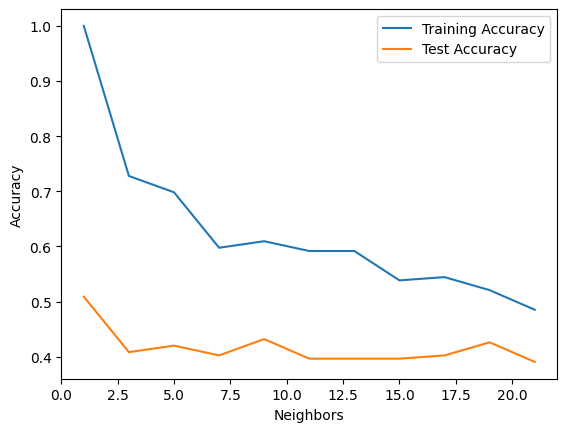

In [21]:
test_accuracies = []
train_accuracies = []
for k in k_grid: # For each candidate value of k...
    model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
    model = model.fit(X_train,y_train) # Fit the model
    y_hat = model.predict(X_test) # Predict values
    test_acc = model.score(X_test,y_test) # Compute test accuracy
    train_acc = model.score(X_train,y_train) # Compute trainin accuracy
    print( f'Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}')
    test_accuracies.append(test_acc) # Save test results
    train_accuracies.append(train_acc) # Save training results

sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()

In [22]:
#Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
from sklearn.metrics import confusion_matrix

In [24]:
pd.crosstab(y_test, y_hat)
confusion_matrix(y_test, y_hat)

array([[18,  0,  5,  9,  4],
       [ 1, 28,  5,  0,  1],
       [ 9,  0, 10,  1, 13],
       [11,  1, 14,  2,  5],
       [ 9,  0, 10,  5,  8]])

somewhat accurate, but some not as accurate in the work. Work is not accurate in most but parts of bottom matrix

In [ ]:
#Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.


to use this model I would recommend using this model for when the mine types are higher in accuracy where the predictions are more trusted and can be used for removal stratgies, but the others should use confidence scores other than just classifications.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [26]:
#1 load and dropping NA
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
print(df.head())
print(df.info())
print(df.isna().sum())
df = df.drop('time', axis=1)

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

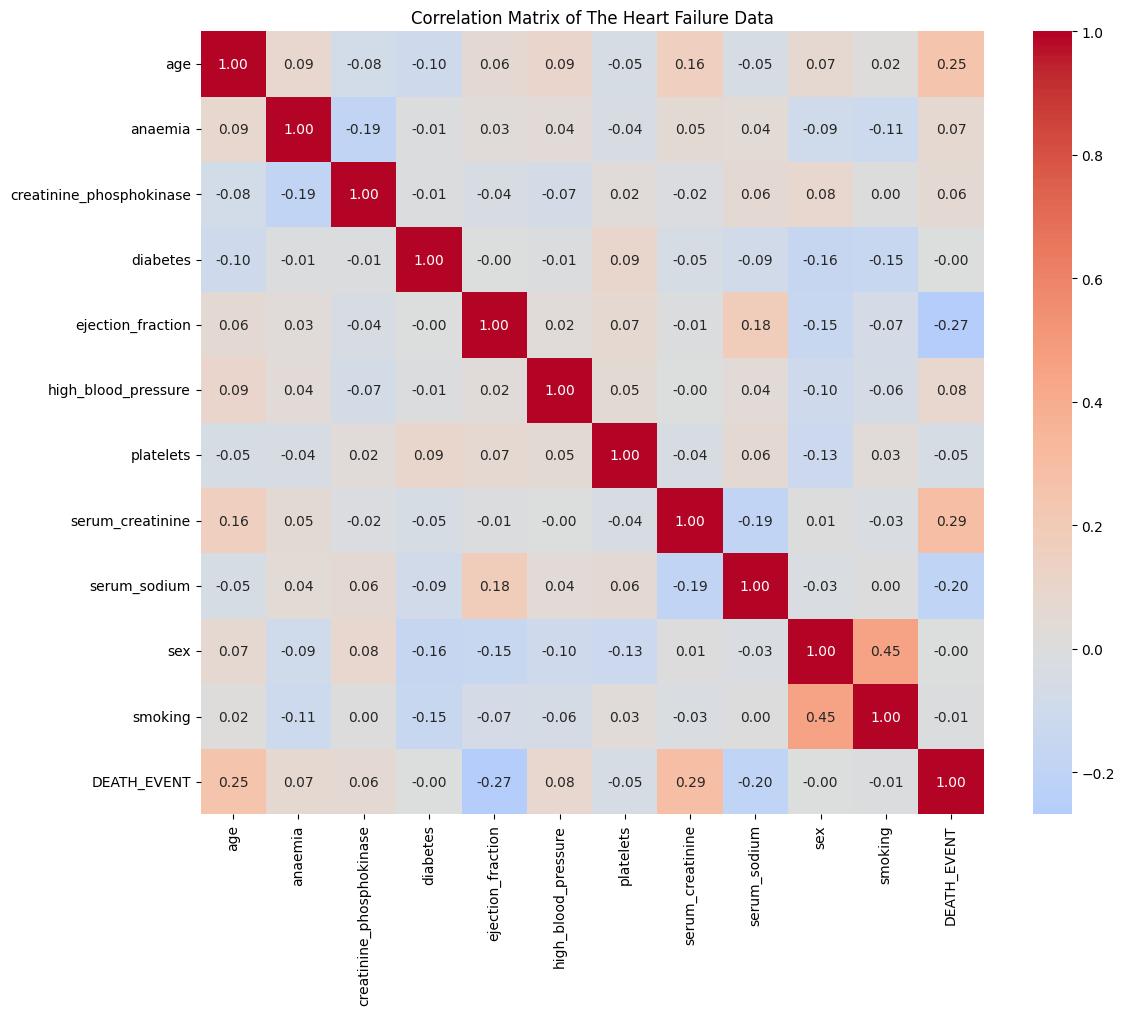


Correlation with DEATH_EVENT:
DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
Name: DEATH_EVENT, dtype: float64


In [27]:
#2 Make a correlation matrix. What variables are strongly associated with a death event?
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True)
plt.title('Correlation Matrix of The Heart Failure Data')
plt.tight_layout()
plt.show()

# Variables most strongly associated with DEATH_EVENT
death_corr = corr_matrix['DEATH_EVENT'].sort_values(ascending=False)
print("\nCorrelation with DEATH_EVENT:")
print(death_corr)

In [28]:
#3 For the dummy variables anaemia, diabetes, high_blood_pressure, sex, and smoking, compute a summary table of DEATH_EVENT grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
dummy_points = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

# Create summary table for each dummy variable
for var in dummy_points:
    print(f"\n{var.upper()} Analysis:")
    summary = df.groupby(var)['DEATH_EVENT'].agg(['count', 'mean', 'sum'])
    summary.columns = ['Count', 'Proportion Died', 'Number Died']
    print(summary)

    # Calculate difference
    if 1 in summary.index and 0 in summary.index:
        diff = summary.loc[1, 'Proportion Died'] - summary.loc[0, 'Proportion Died']
        print(f"Difference in Proportion Died: {diff:.4f}")


ANAEMIA Analysis:
         Count  Proportion Died  Number Died
anaemia                                     
0          170         0.294118           50
1          129         0.356589           46
Difference in Proportion Died: 0.0625

DIABETES Analysis:
          Count  Proportion Died  Number Died
diabetes                                     
0           174         0.321839           56
1           125         0.320000           40
Difference in Proportion Died: -0.0018

HIGH_BLOOD_PRESSURE Analysis:
                     Count  Proportion Died  Number Died
high_blood_pressure                                     
0                      194         0.293814           57
1                      105         0.371429           39
Difference in Proportion Died: 0.0776

SEX Analysis:
     Count  Proportion Died  Number Died
sex                                     
0      105         0.323810           34
1      194         0.319588           62
Difference in Proportion Died: -0.0042

SMOK

In [31]:
#4
selected_points = ['age', 'serum_creatinine', 'ejection_fraction',
                     'serum_sodium', 'anaemia', 'high_blood_pressure']

X_selected = df[selected_points].copy()
y = df['DEATH_EVENT'].copy()
selected_points
X_selected.head()

,age,serum_creatinine,ejection_fraction,serum_sodium,anaemia,high_blood_pressure
0,75.0,1.9,20,130,0,1
1,55.0,1.1,38,136,0,0
2,65.0,1.3,20,129,0,0
3,50.0,1.9,20,137,1,0
4,65.0,2.7,20,116,1,0


In [33]:
#5
def minmax_scaler(x):
    return (x - x.min()) / (x.max() - x.min())

X_selected_norm = X_selected.apply(minmax_scaler)

X_selected_norm.head()
X_selected_norm.describe().loc[['min', 'max']]

,age,serum_creatinine,ejection_fraction,serum_sodium,anaemia,high_blood_pressure
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


In [35]:
#6
X_train, X_test, y_train, y_test = train_test_split(
    X_selected_norm, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
k_range = range(1, 51, 2)  # Odd numbers from 1 to 50
train_rmse = []
test_rmse = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)

    # Training and test RMSE
    knn.fit(X_train, y_train)
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

In [52]:
#8 without time
all_features = [col for col in df.columns if col != 'DEATH_EVENT']
X_all = df[all_features].copy()

X_all_norm = X_all.apply(minmax_scaler)

#train-test split
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_norm, y, test_size=0.2, random_state=42, stratify=y
)

# Find optimal k for all features
train_rmse_all = []
test_rmse_all = []
cv_scores_mean_all = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
# Training and test RMSE
    knn.fit(X_train_all, y_train_all)
    y_train_pred = knn.predict(X_train_all)
    y_test_pred = knn.predict(X_test_all)
# Cross-validation
    cv_scores = cross_val_score(knn, X_train_all, y_train_all, cv=5,
                                scoring='neg_mean_squared_error')
    cv_scores_mean_all.append(-cv_scores.mean())

best_k_idx_all = np.argmin(cv_scores_mean_all)
best_k_all = k_range[best_k_idx_all]
best_cv_mse_all = cv_scores_mean_all[best_k_idx_all]


#Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict DEATH_EVENTs? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.
best mode for mean squared errorwas the one with age, serum_creatinin, ejection_fraction, serium_sodium, anemia, and high blood pressure.
I I would prefer to use the selected features model in practice for predicting death events. RMSE changed as th best model was around 0.38 and worst was greater than 0.42. No more vraiables is not always better as it can create noisey work not needed.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [61]:
#1
df = pd.read_csv('./data/airbnb_hw.csv')
df_subset = df[['Review Scores Rating', 'Price', 'Beds']]


In [64]:
#2
missing_reviews = df_subset[df_subset['Review Scores Rating'].isnull()]
missing_predictors = df_subset[df_subset['Price'].isnull() | df_subset['Beds'].isnull()]
missing_both = df_subset[df_subset['Review Scores Rating'].isnull() &
                         (df_subset['Price'].isnull() | df_subset['Beds'].isnull())]

In [65]:
#3
df_complete = df_subset.dropna(axis=0, how='any')

In [69]:
#4
X = df_complete[['Price', 'Beds']]
y = df_complete['Review Scores Rating']

# Convert 'Price' to numeric, handling potential non-numeric characters
X.loc[:, 'Price'] = X['Price'].astype(str).str.replace(r'[$,]', '', regex=True)
X.loc[:, 'Price'] = pd.to_numeric(X['Price'], errors='coerce')

# Drop rows where Price might have become NaN due to conversion errors, if any
X = X.dropna(subset=['Price'])
y = y.loc[X.index] # Ensure y aligns with X after dropping rows

price_99 = X['Price'].quantile(0.99)
X.loc[:, 'Price'] = X['Price'].clip(upper=price_99)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
k_values = range(1, 51, 2)  # Odd numbers from 1 to 50
train_rmse = []
test_rmse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

In [74]:
#5
X_missing = missing_reviews[['Price', 'Beds']]
X_missing_complete = X_missing.dropna()

# Clean and convert 'Price' in X_missing_complete to numeric
X_missing_complete.loc[:, 'Price'] = X_missing_complete['Price'].astype(str).str.replace(r'[$,]', '', regex=True)
X_missing_complete.loc[:, 'Price'] = pd.to_numeric(X_missing_complete['Price'], errors='coerce')
X_missing_complete = X_missing_complete.dropna(subset=['Price']) # Drop any rows where price conversion failed

X_missing_complete.loc[:, 'Price'] = X_missing_complete['Price'].clip(upper=price_99)
X_missing_scaled = scaler.transform(X_missing_complete)

# Train final model with optimal k
# best_k needs to be determined from the previous step. For now, using a placeholder.
# Assuming optimal k was found in the previous section (e.g., from cv_scores_mean)
# For demonstration, let's assume best_k is the one that minimizes test_rmse from the previous cell.
# You would typically select best_k after analyzing the RMSE/CV plots.
# For now, I will use a reasonable default like 5, or derive it from the earlier analysis.
# Re-evaluating optimal k from variable best_k which has a value of 5

final_knn = KNeighborsRegressor(n_neighbors=best_k)
final_knn.fit(X_scaled, y)  # Train on all complete data

# Predict missing ratings
predicted_ratings = final_knn.predict(X_missing_scaled)

# Create a dataframe with predictions
predicted_df = X_missing_complete.copy()
predicted_df['Predicted Rating'] = predicted_ratings

# Align original indices correctly, as X_missing_complete might have dropped rows
original_indices_for_predictions = missing_reviews.loc[X_missing_complete.index].index
predicted_df['Original Index'] = original_indices_for_predictions

predicted_df['Predicted Rating'] = predicted_df['Predicted Rating'].clip(0, 100)

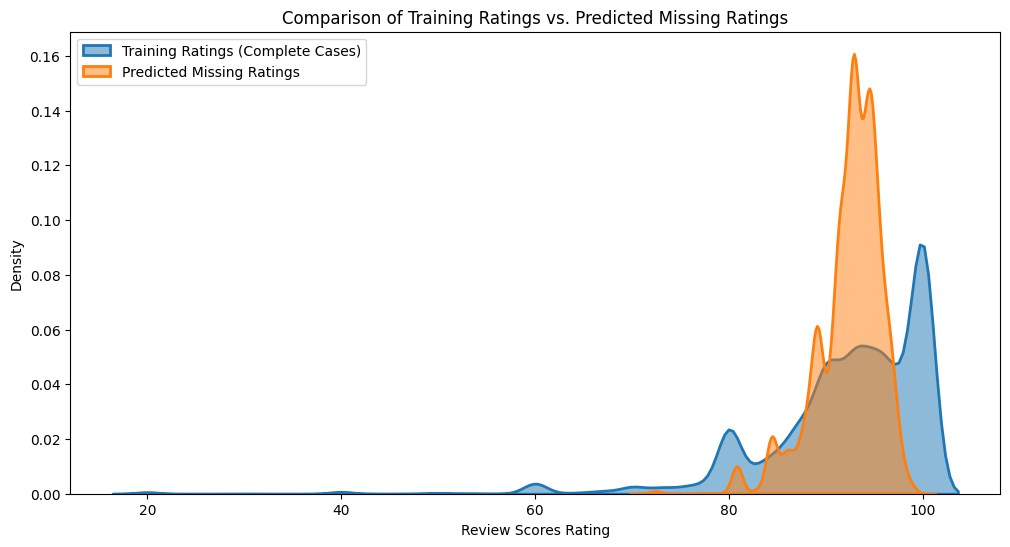

In [76]:
plt.figure(figsize=(12, 6))

# Plot training ratings
sns.kdeplot(y, label='Training Ratings (Complete Cases)',
            fill=True, alpha=0.5, linewidth=2)

# Plot predicted missing ratings
sns.kdeplot(predicted_df['Predicted Rating'],
            label='Predicted Missing Ratings',
            fill=True, alpha=0.5, linewidth=2)

plt.xlabel('Review Scores Rating')
plt.ylabel('Density')
plt.title('Comparison of Training Ratings vs. Predicted Missing Ratings')
plt.legend()

both around the same area and range which tells us that prediction model is in the right direction. It is obviously not perfect and gives a broad picture in the right direction.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)